$$\frac{\partial h}{\partial t}=U+K_d\Bigl(\frac{\partial^2h}{\partial x^2}+\frac{\partial^2h}{\partial y^2}\Bigr)$$
$$h(t=0)=h_0(x,y)$$
$$h(x=0)=0,\ h(x=L_x)=0,\ h(y=0)=0,\ h(y=L_y)=0$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [16]:
Lx = 2000
Ly = 1000
nx = 201
ny = 101
dx = Lx/(nx - 1)
dy = Ly/(ny - 1)
Kd = 1e-2
U = 1e-4
dt = 1000
Courant = [dt*Kd/dx**2,dt*Kd/dy**2]
print(Courant)
nstep = 10000

[0.1, 0.1]


$$h_{i,j}=h_{i,j}+U\Delta t+K_d\Delta t\Bigl(\frac{h_{i+1,j}-2h_{i,j}+h_{i-1,j}}{\Delta x^2}+\frac{h_{i,j+1}-2h_{i,j}+h_{i,j-1}}{\Delta y^2}\Bigr)$$

In [17]:
h = np.zeros((ny,nx))

for step in range(nstep):
    h[1:-1,1:-1] = h[1:-1,1:-1] + U*dt # to impose the uplift
    h[1:-1,1:-1] = h[1:-1,1:-1] + Kd*dt*(
                                  (h[1:-1,2:]-2*h[1:-1,1:-1]+h[1:-1,:-2])/dx**2
                                + (h[2:,1:-1]-2*h[1:-1,1:-1]+h[:-2,1:-1])/dy**2
                                  )# to solve the 2D diffusion equation

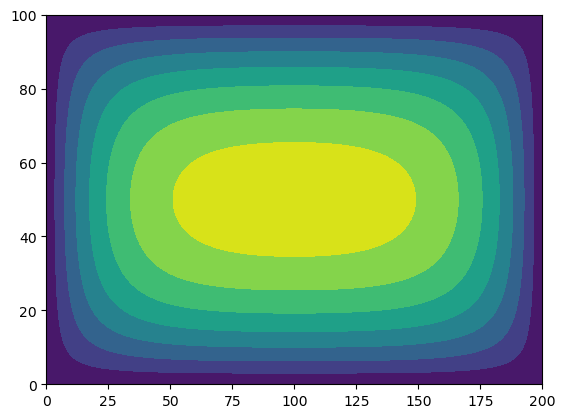

In [18]:
plt.contourf(h)

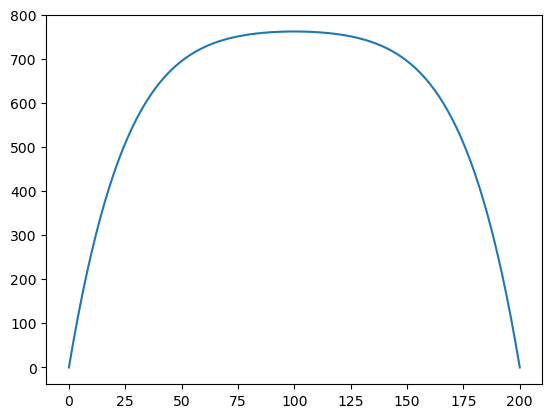

In [19]:
plt.plot(h[51,:])